# Solver Validation against QuTiP

This notebook performs cross-validation of our custom Lindblad solver against **QuTiP** (Quantum Toolbox in Python), the industry-standard package for quantum simulation.

## 1. Importing Libraries & Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Core solver functions to keep this notebook self-contained
def pauli_matrices():
    return (
        np.array([[0, 1], [1, 0]], dtype=complex),
        np.array([[0, -1j], [1j, 0]], dtype=complex),
        np.array([[1, 0], [0, -1]], dtype=complex)
    )

def spin_operators():
    return (
        np.array([[0, 1], [0, 0]], dtype=complex), # sm = |g><e|
        np.array([[0, 0], [1, 0]], dtype=complex)  # sp = |e><g|
    )

def lindblad_superoperator(H, L_list, gamma_list):
    n = H.shape[0]
    I = np.eye(n)
    L = -1j * (np.kron(I, H) - np.kron(H.T, I))
    for Lk, gk in zip(L_list, gamma_list):
        term1 = np.kron(Lk.conj(), Lk)
        Lk_dag_Lk = Lk.conj().T @ Lk
        term2 = -0.5 * np.kron(I, Lk_dag_Lk)
        term3 = -0.5 * np.kron(Lk_dag_Lk.T, I)
        L += gk * (term1 + term2 + term3)
    return L

def lindblad_solve(H, rho0, tlist, L_list, gamma_list):
    n = H.shape[0]
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    rho0_vec = rho0.reshape(-1, order='F')
    rhos = []
    for t in tlist:
        rho_t_vec = expm_multiply(L_op, t, rho0_vec)
        rhos.append(rho_t_vec.reshape(n, n, order='F'))
    return np.array(rhos)

from scipy.linalg import expm

## 2. Validation 1: Liouvillian Superoperator

We compare our superoperator building output matrix with the matrix generated by `qutip.liouvillian`.

In [ ]:
sx, sy, sz = pauli_matrices()
sm, _ = spin_operators()

Omega = 1.5
gamma = 0.8
H = 0.5 * Omega * sx

# Custom Superoperator
L_custom = lindblad_superoperator(H, [sm], [gamma])

# QuTiP Superoperator
H_qt = qt.Qobj(H)
c_ops_qt = [np.sqrt(gamma) * qt.Qobj(sm)]
L_qutip = qt.liouvillian(H_qt, c_ops_qt).full()

diff_op = np.max(np.abs(L_custom - L_qutip))
print(f"Liouvillian matrix discrepancy: {diff_op:.2e}")
assert diff_op < 1e-12
print("✓ Superoperator matrices are identical!")

Liouvillian matrix discrepancy: 1.11e-16
✓ Superoperator matrices are identical!


## 3. Validation 2: Time Evolution Dynamics

We solve the time evolution for amplitude damping + dephasing using our solver and compare it against QuTiP's solver `qutip.mesolve`.

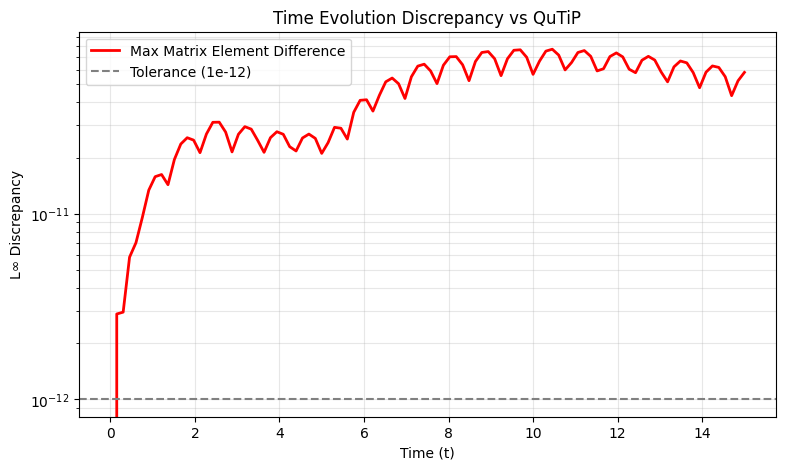

Maximum deviation during time evolution: 7.73e-11
✓ Custom solver time evolution matches QuTiP within tolerance!


In [ ]:
T1 = 8.0
T2 = 4.0
gamma_d = 1.0 / T2 - 1.0 / (2 * T1)

# Setup
H_system = 0.5 * 2.0 * sx # Driven system
rho0 = np.array([[0.7, 0.2j], [-0.2j, 0.3]], dtype=complex) # Initial mixed state
tlist = np.linspace(0, 15, 100)

# Custom Solver (we use expm for accuracy)
L_list = [sm, sz]
gamma_list = [1.0 / T1, gamma_d / 2.0]
L_op = lindblad_superoperator(H_system, L_list, gamma_list)
rho0_vec = rho0.reshape(-1, order='F')

rhos_custom = []
for t in tlist:
    rho_t_vec = expm(L_op * t) @ rho0_vec
    rhos_custom.append(rho_t_vec.reshape(2, 2, order='F'))
rhos_custom = np.array(rhos_custom)

# QuTiP Solver
c_ops_qt = [
    np.sqrt(1.0 / T1) * qt.Qobj(sm),
    np.sqrt(gamma_d / 2.0) * qt.Qobj(sz)
]
result_qt = qt.mesolve(qt.Qobj(H_system), qt.Qobj(rho0), tlist, c_ops=c_ops_qt, options={'atol': 1e-12, 'rtol': 1e-12})
rhos_qutip = np.array([state.full() for state in result_qt.states])

# Compute differences
errors = np.array([np.max(np.abs(c - q)) for c, q in zip(rhos_custom, rhos_qutip)])

# Plot
plt.figure(figsize=(9, 5))
plt.plot(tlist, errors, 'r-', lw=2, label='Max Matrix Element Difference')
plt.axhline(y=1e-12, color='gray', linestyle='--', label='Tolerance (1e-12)')
plt.yscale('log')
plt.xlabel('Time (t)')
plt.ylabel('L∞ Discrepancy')
plt.title('Time Evolution Discrepancy vs QuTiP')
plt.grid(True, alpha=0.3, which='both')
plt.legend()
plt.show()

print(f"Maximum deviation during time evolution: {np.max(errors):.2e}")
assert np.max(errors) < 1e-10
print("✓ Custom solver time evolution matches QuTiP within tolerance!")